<a href="https://colab.research.google.com/github/ashabb-ipl/iplCapstoneForPredictiveAI/blob/main/AnomalyDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Start

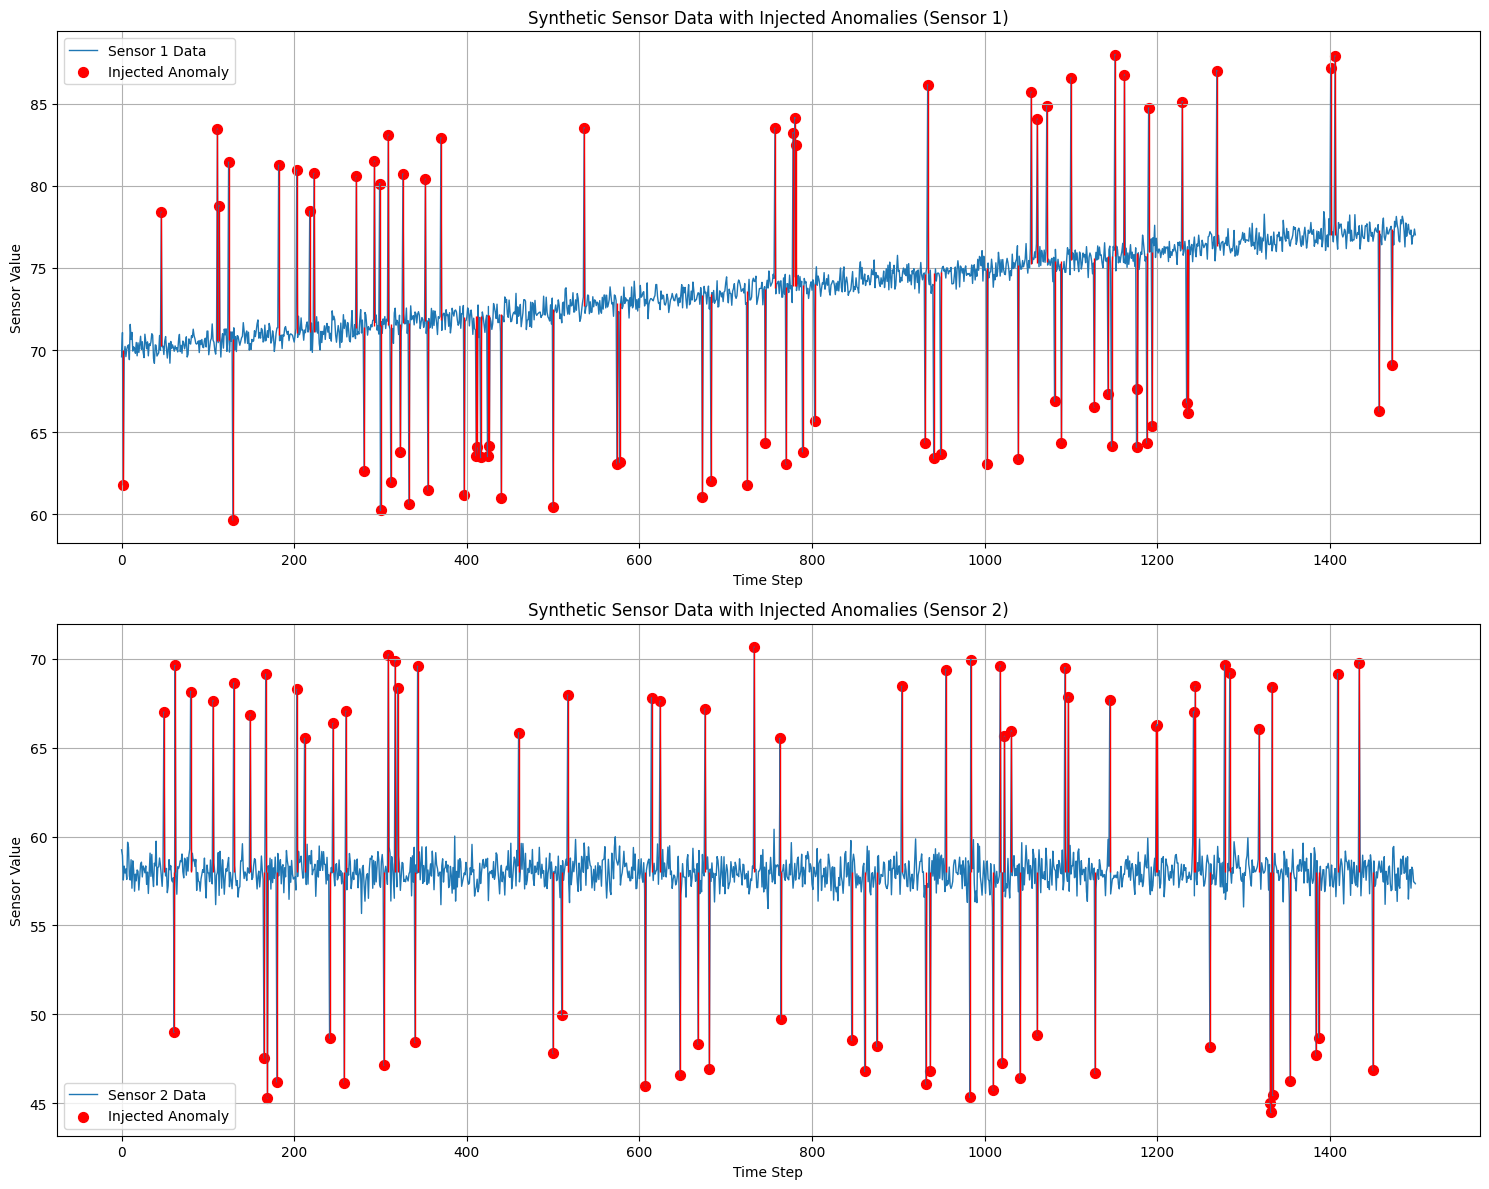

Synthetic data generation complete. Variables 'sensor_1_data', 'sensor_2_data', 'injected_anomaly_indices_1', and 'injected_anomaly_indices_2' are now defined.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameters for Synthetic Data Generation ---
N_SAMPLES = 1500  # Total number of time steps
BASE_VALUE_1 = 70 # Base value for Sensor 1
BASE_VALUE_2 = 58 # Base value for Sensor 2
TREND_SLOPE_1 = 0.005 # Slight upward trend for Sensor 1
NOISE_LEVEL = 0.5 # Random noise level
NUM_ANOMALIES = 75 # Number of anomalies to inject (approx 5% of N_SAMPLES)
ANOMALY_MAGNITUDE = 10 # How much anomalies deviate from the normal

# --- Generate Synthetic Sensor 1 Data ---
time_steps = np.arange(N_SAMPLES)
sensor_1_data = BASE_VALUE_1 + (TREND_SLOPE_1 * time_steps) + np.random.normal(0, NOISE_LEVEL, N_SAMPLES)

# --- Inject Anomalies into Sensor 1 ---
injected_anomaly_indices_1 = np.random.choice(N_SAMPLES, NUM_ANOMALIES, replace=False)
for idx in injected_anomaly_indices_1:
    # Randomly make anomaly a spike or a dip
    if np.random.rand() > 0.5:
        sensor_1_data[idx] += ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2) # Spike
    else:
        sensor_1_data[idx] -= ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2) # Dip

# --- Generate Synthetic Sensor 2 Data ---
# Sensor 2 will be more stable, less trend
sensor_2_data = BASE_VALUE_2 + np.random.normal(0, NOISE_LEVEL * 1.5, N_SAMPLES) # Slightly more noise for variety

# --- Inject Anomalies into Sensor 2 ---
injected_anomaly_indices_2 = np.random.choice(N_SAMPLES, NUM_ANOMALIES, replace=False)
for idx in injected_anomaly_indices_2:
    if np.random.rand() > 0.5:
        sensor_2_data[idx] += ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2)
    else:
        sensor_2_data[idx] -= ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2)

# --- Plot the Generated Data (as seen in your image) ---
plt.figure(figsize=(15, 12))

# Plot for Sensor 1
plt.subplot(2, 1, 1)
plt.plot(time_steps, sensor_1_data, label='Sensor 1 Data', linewidth=1)
plt.scatter(injected_anomaly_indices_1, sensor_1_data[injected_anomaly_indices_1], color='red', s=50, label='Injected Anomaly')
# Add vertical lines for anomalies for better visibility, similar to your image
for idx in injected_anomaly_indices_1:
    plt.vlines(idx, min(sensor_1_data[idx], BASE_VALUE_1 + (TREND_SLOPE_1 * idx)), max(sensor_1_data[idx], BASE_VALUE_1 + (TREND_SLOPE_1 * idx)), color='red', linestyle='-', linewidth=1)

plt.title('Synthetic Sensor Data with Injected Anomalies (Sensor 1)')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.legend()

# Plot for Sensor 2
plt.subplot(2, 1, 2)
plt.plot(time_steps, sensor_2_data, label='Sensor 2 Data', linewidth=1)
plt.scatter(injected_anomaly_indices_2, sensor_2_data[injected_anomaly_indices_2], color='red', s=50, label='Injected Anomaly')
# Add vertical lines for anomalies
for idx in injected_anomaly_indices_2:
    plt.vlines(idx, min(sensor_2_data[idx], BASE_VALUE_2), max(sensor_2_data[idx], BASE_VALUE_2), color='red', linestyle='-', linewidth=1)

plt.title('Synthetic Sensor Data with Injected Anomalies (Sensor 2)')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Synthetic data generation complete. Variables 'sensor_1_data', 'sensor_2_data', 'injected_anomaly_indices_1', and 'injected_anomaly_indices_2' are now defined.")

Data saved to isolation_forest_training_data.csv
Shape of data for IsolationForest: (1500, 2)

First 5 rows of combined sensor data:
   Sensor_1_Value  Sensor_2_Value
0       69.592003       59.253844
1       71.065719       58.938746
2       61.786880       57.555013
3       69.727236       58.337277
4       70.221158       57.949283

Training IsolationForest model...
IsolationForest model training complete!

First 10 rows with anomaly scores and predictions:
   Sensor_1_Value  Sensor_2_Value  anomaly_score  is_anomaly
0       69.592003       59.253844       0.177645           1
1       71.065719       58.938746       0.230262           1
2       61.786880       57.555013       0.008619           1
3       69.727236       58.337277       0.226436           1
4       70.221158       57.949283       0.240246           1
5       69.599388       58.176993       0.219030           1
6       70.043368       57.588535       0.236833           1
7       70.235348       59.681320       0.15120

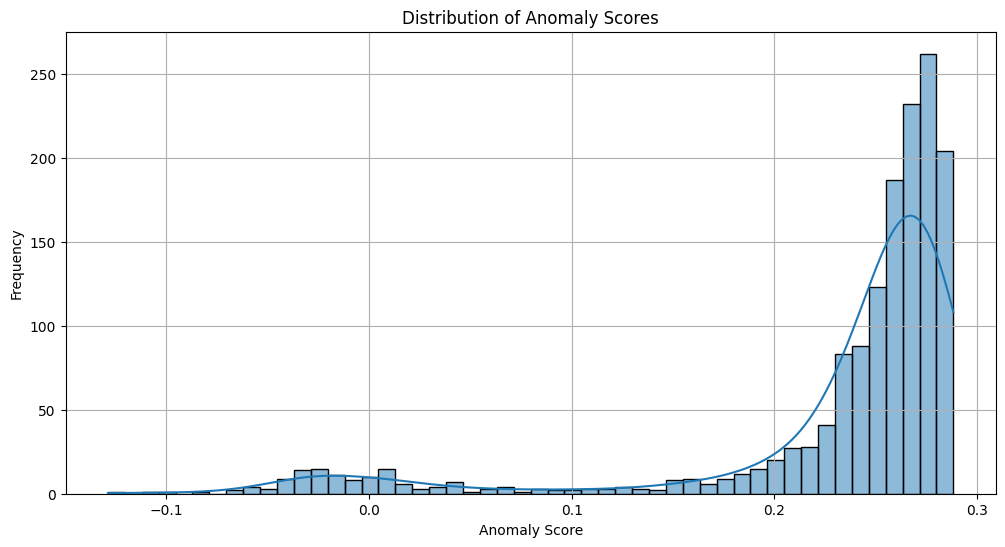

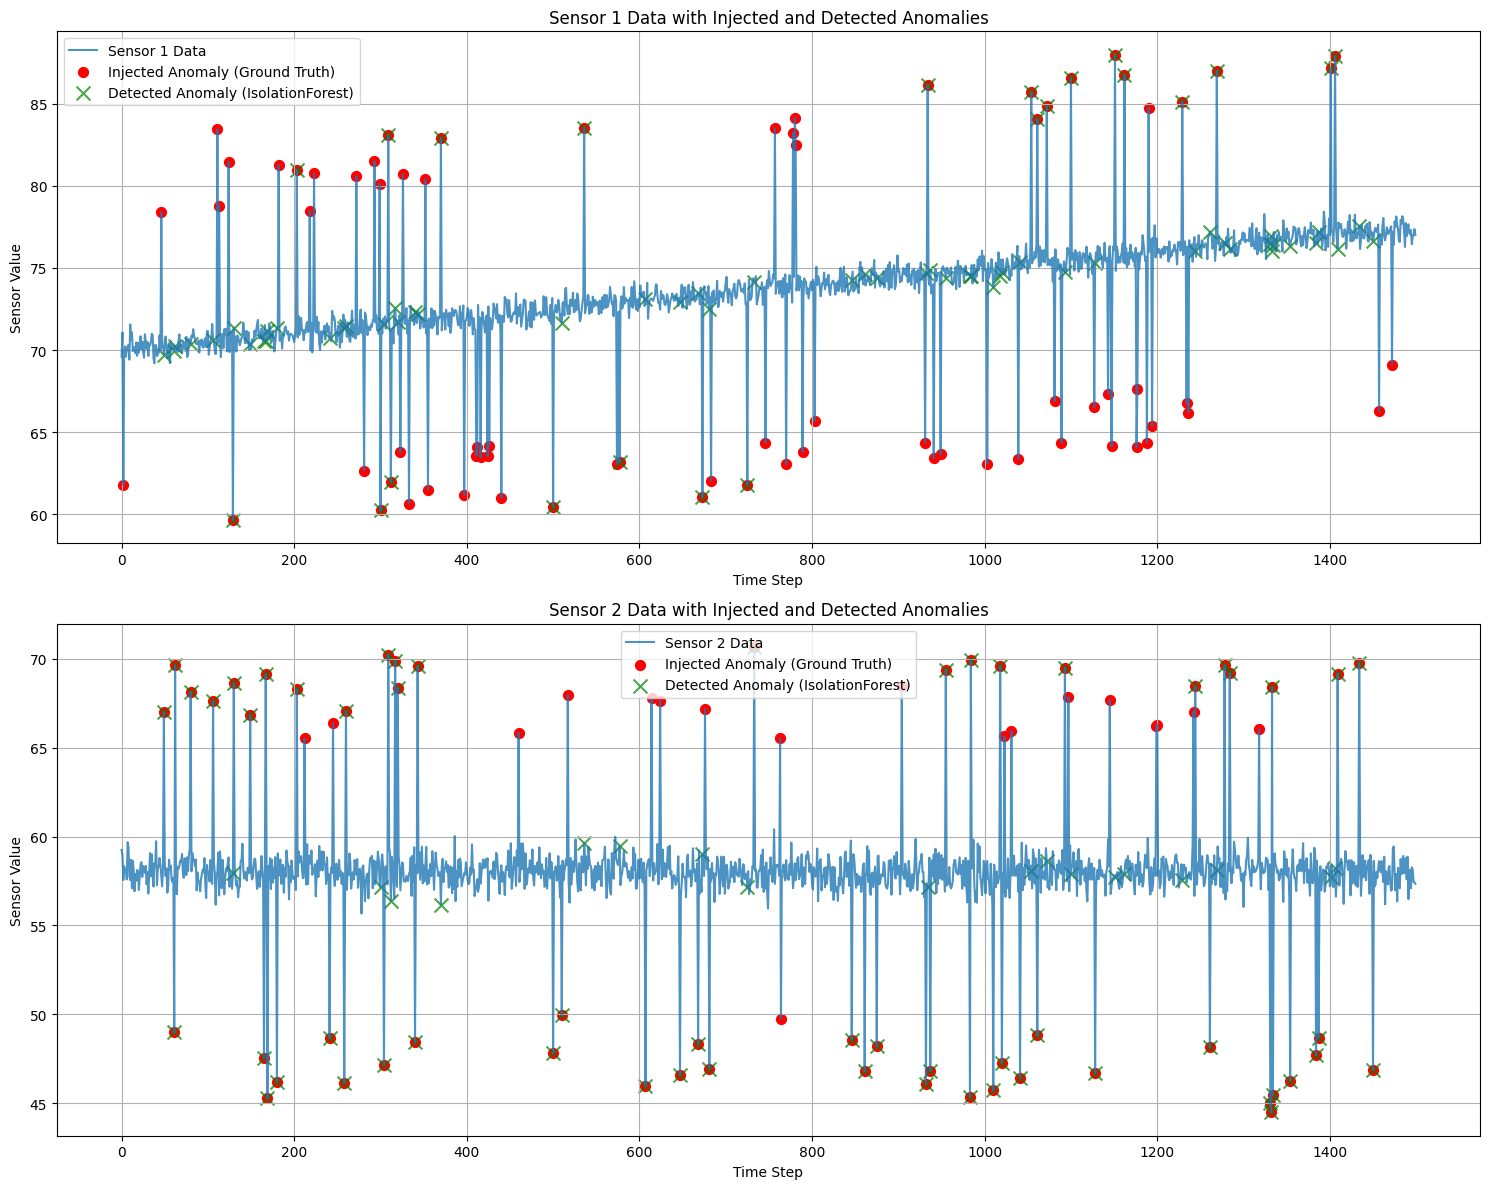

In [17]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming sensor_1_data and sensor_2_data are already defined from previous steps
# If not, you'd need to re-run the data generation code.

# 1. Combine sensor data into a DataFrame for IsolationForest
# IsolationForest expects a 2D array, where each row is a sample and each column is a feature.
# Here, our features are the values from Sensor 1 and Sensor 2 at each time step.
data_for_model = pd.DataFrame({
    'Sensor_1_Value': sensor_1_data,
    'Sensor_2_Value': sensor_2_data
})
# Save the DataFrame to a CSV file
data_for_model.to_csv('isolation_forest_training_data.csv', index=False)
print("Data saved to isolation_forest_training_data.csv")

print("Shape of data for IsolationForest:", data_for_model.shape)
print("\nFirst 5 rows of combined sensor data:")
print(data_for_model.head())

# 2. Initialize and Train the IsolationForest Model
# n_estimators: The number of base estimators (trees) in the ensemble. More trees generally lead to better performance but take longer.
# contamination: The proportion of outliers in the data set. This is a crucial parameter.
#                If you know roughly what percentage of your data is anomalous, you can set it.
#                If not, a common practice is to start with a small value (e.g., 0.01 to 0.1) or 'auto'.
#                For our synthetic data, we injected a known percentage of anomalies, so we can use that.
#                Let's assume we injected about 5% anomalies for demonstration.
# random_state: For reproducibility.
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Fit the model to our combined sensor data
# The fit method trains the model to understand the 'normal' patterns in the data.
print("\nTraining IsolationForest model...")
model.fit(data_for_model) # Model is fit on 'Sensor_1_Value' and 'Sensor_2_Value'
print("IsolationForest model training complete!")

# 3. Generate Anomaly Scores
# The decision_function method computes the anomaly score for each sample.
# Lower scores indicate a higher likelihood of being an anomaly.
data_for_model['anomaly_score'] = model.decision_function(data_for_model[['Sensor_1_Value', 'Sensor_2_Value']]) # IMPORTANT: Only pass original features

# 4. Predict Anomalies
# The predict method returns -1 for outliers and 1 for inliers.
# This classification is based on the 'contamination' parameter set during initialization.
data_for_model['is_anomaly'] = model.predict(data_for_model[['Sensor_1_Value', 'Sensor_2_Value']]) # IMPORTANT: Only pass original features

print("\nFirst 10 rows with anomaly scores and predictions:")
print(data_for_model.head(10))

# Let's see how many anomalies were detected
num_detected_anomalies = data_for_model[data_for_model['is_anomaly'] == -1].shape[0]
print(f"\nNumber of detected anomalies by IsolationForest: {num_detected_anomalies}")

# Quick visualization of anomaly scores
plt.figure(figsize=(12, 6))
sns.histplot(data_for_model['anomaly_score'], bins=50, kde=True)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# You can also visualize the detected anomalies on our original plots
# Let's add the detected anomalies to the original plot for comparison

# Get the indices of the detected anomalies
detected_anomaly_indices = data_for_model[data_for_model['is_anomaly'] == -1].index

plt.figure(figsize=(15, 12))

# Plot for Sensor 1
plt.subplot(2, 1, 1)
plt.plot(sensor_1_data, label='Sensor 1 Data', alpha=0.8)
plt.scatter(injected_anomaly_indices_1, sensor_1_data[injected_anomaly_indices_1], color='red', s=50, label='Injected Anomaly (Ground Truth)')
plt.scatter(detected_anomaly_indices, sensor_1_data[detected_anomaly_indices], color='green', marker='x', s=100, label='Detected Anomaly (IsolationForest)', alpha=0.7)
plt.title('Sensor 1 Data with Injected and Detected Anomalies')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.legend()

# Plot for Sensor 2
plt.subplot(2, 1, 2)
plt.plot(sensor_2_data, label='Sensor 2 Data', alpha=0.8)
plt.scatter(injected_anomaly_indices_2, sensor_2_data[injected_anomaly_indices_2], color='red', s=50, label='Injected Anomaly (Ground Truth)')
plt.scatter(detected_anomaly_indices, sensor_2_data[detected_anomaly_indices], color='green', marker='x', s=100, label='Detected Anomaly (IsolationForest)', alpha=0.7)
plt.title('Sensor 2 Data with Injected and Detected Anomalies')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()